# Projet de Télédétection : Suivi des Landes en Bretagne (2023-2024)
## Étudiant : Nicolas DEMBELE

### Introduction : Cartographie et Suivi des Landes Bretonnes par Télédétection
#### Contexte de l'étude
Les landes, milieux caractéristiques des paysages bretons, représentent des réservoirs de biodiversité essentiels mais fragiles. Composées majoritairement d'Éricacées (bruyères), elles sont aujourd'hui menacées par le changement climatique, la fermeture des milieux ou l'urbanisation. Dans le cadre de la mission SIGMA M2, ce projet vise à exploiter les capacités de la télédétection spatiale pour cartographier avec précision ces strates de végétation.

#### L'enjeu est de taille : distinguer des formations végétales qui, au premier abord, peuvent présenter des signatures spectrales proches, comme les prairies rases ou les jeunes formations forestières.

Problématique technique
L'utilisation d'une simple image satellite unique est souvent insuffisante pour caractériser des milieux naturels complexes. C'est pourquoi ce projet s'appuie sur :

La dimension temporelle : Utilisation d'une série chronologique d'images Sentinel-2 (période 2023-2024) pour capturer les cycles de vie de la végétation (phénologie).

##### L'analyse biochimique : L'utilisation d'indices spécifiques comme le NARI (Normalized Anthocyanin Reflectance Index), capable de détecter la présence d'anthocyanes, pigments caractéristiques des landes durant certaines phases de leur développement.

### Objectifs du projet
L'objectif principal est de produire une carte d'occupation du sol précise au pixel (10m de résolution) sur le site d'étude en Bretagne. Pour y parvenir, la démarche s'articule autour de trois axes :

### Analyse exploratoire : Étudier la représentativité des échantillons (données de photo-interprétation) et la dynamique temporelle des indices de végétation.

Modélisation statistique : Mettre en œuvre un algorithme de forêt aléatoire (Random Forest) optimisé par une recherche d'hyperparamètres pour garantir la fiabilité de la classification.

Évaluation et Critique : Valider la qualité de la production via des matrices de confusion et analyser la pertinence des variables spectrales utilisées.
## 1. Initialisation et Importations
Cette section configure l'environnement de travail et charge les modules nécessaires, y compris libsigma et nos fonctions personnalisées.

In [4]:
import os 
import sys
import importlib

# 1. Configuration du chemin d'accès prioritaire
sys.path.insert(0, '/home/onyxia/work')

# 2. Librairies standards et géospatiales
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt 
import geopandas as gpd

# 3. Librairie du cours (libsigma)
from libsigma import classification as cla
from libsigma.read_and_write import open_image, load_img_as_array, write_image

# 4. Import de TA fonction
import my_function as mf
importlib.reload(mf)
from my_function import rasterisation

print(f"Environnement prêt. Fonctions chargées depuis : {mf.__file__}")

Environnement prêt. Fonctions chargées depuis : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/my_function.py


Dans cette étape, j'analyse mes données de terrain pour vérifier la qualité de mes échantillons. Je commence par charger le fichier de formes (Shapefile) pour m'assurer que les quatre classes de végétation (Sol nu, Landes, Arbres, Herbe) sont bien présentes.

Ensuite, je compte le nombre de polygones pour chaque catégorie afin de vérifier que mon jeu de données est équilibré : il est essentiel d'avoir assez d'exemples pour chaque strate pour que l'algorithme apprenne correctement. Enfin, je génère une carte de répartition spatiale pour confirmer que mes échantillons sont bien dispersés sur toute la zone d'étude en Bretagne, ce qui garantit que mon modèle sera représentatif de l'ensemble du territoire et non d'un seul secteur précis.

Codes des classes : [3 2 4]
Nombre de polygones par strate :
strate
3    121
2     86
4     71
Name: count, dtype: int64


Text(0.5, 1.0, 'Répartition spatiale des échantillons')

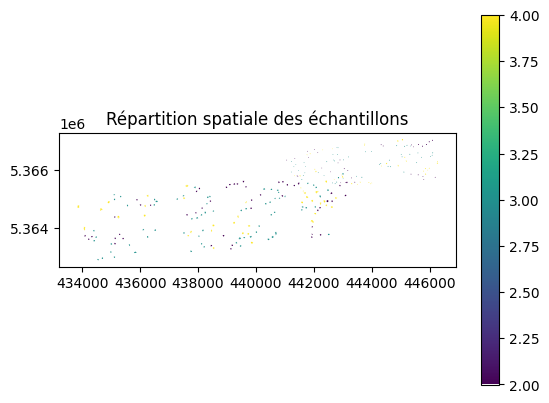

In [5]:
# cellule (Analyse des échantillons)
gdf = gpd.read_file("/home/onyxia/work/data/projet_eval/PI_strates_bretagne_32630.shp")

# Affiche les codes des classes présentes
gpf = gdf["strate"].unique()
print(f"Codes des classes : {gpf}")

# Affiche le nombre de polygones par classe
gbf = gdf["strate"].value_counts()
print("Nombre de polygones par strate :")
print(gbf)

# Ajout d'un graphique
gdf.plot(column='strate', legend=True)
plt.title("Répartition spatiale des échantillons")

Dans cette partie, mon objectif est de transformer les statistiques brutes de mes échantillons en un graphique clair et visuel.

Organisation : Je commence par créer automatiquement un dossier results/figure pour que mes résultats soient bien rangés.

Clarté : Pour que le graphique soit lisible par tous, je remplace les codes numériques (2, 3, 4) par des noms concrets : "Herbe", "Landes" et "Arbres".

Mise en forme : J ai choisi des couleurs spécifiques (orange pour les landes, vert pour les arbres) et j ai ajouté le nombre exact de polygones au-dessus de chaque barre pour que lon puisse lire les chiffres précisément.

Export : Je sauvegarde le graphique en haute définition (dpi=300) pour qu il soit propre.


Graphique avec étiquettes sauvegardé : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/figure/diag_baton_nb_poly_by_class.png


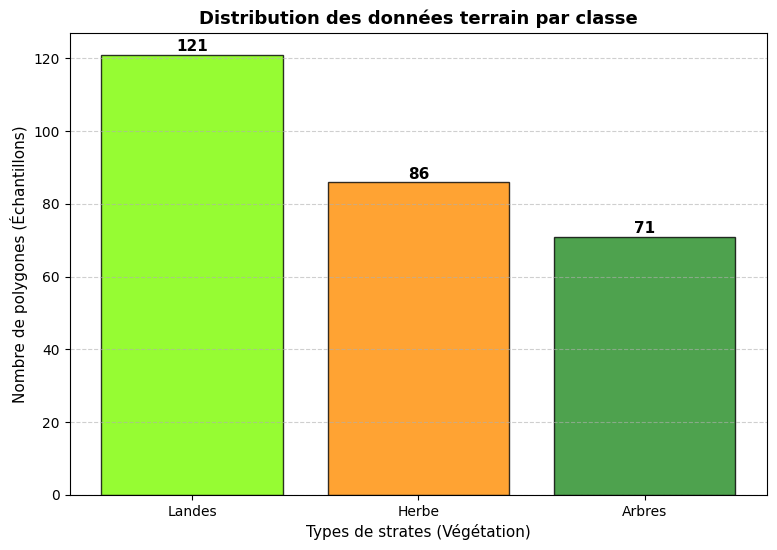

In [6]:
import os
import matplotlib.pyplot as plt

# =================================================================
# 1. PRÉPARATION DES RÉPERTOIRES
# =================================================================
fig_dir = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/figure'
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
    print(f"Dossier créé : {fig_dir}")

# --- 2. Préparation des données ---
noms_strates = {2: "Herbe", 3: "Landes", 4: "Arbres"}
labels = [noms_strates.get(code, f"Classe {code}") for code in gpf]

# --- 3. Création du graphique ---
plt.figure(figsize=(9, 6))
couleurs = ['#7cfc00', '#ff8c00', '#228b22']

# Création des barres
bars = plt.bar(labels, gbf, color=couleurs, edgecolor='black', alpha=0.8)

# --- AJOUT DU NOMBRE DE POLYGONES SUR LE GRAPH ---
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height)}', # Affiche la valeur entière
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# --- 4. Mise en forme et Titres ---
plt.xlabel("Types de strates (Végétation)", fontsize=11)
plt.ylabel("Nombre de polygones (Échantillons)", fontsize=11)
plt.title("Distribution des données terrain par classe", fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# --- 5. Sauvegarde ---
output_path = os.path.join(fig_dir, 'diag_baton_nb_poly_by_class.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

print(f"Graphique avec étiquettes sauvegardé : {output_path}")
plt.show()

Le diagramme en bâtons me permet de tirer plusieurs conclusions importantes pour la suite de mon travail :

Répartition des classes : On observe que les classes sont bien représentées. Même si certaines strates ont plus d'échantillons que d'autres, le volume de données pour les Landes (Classe 3) est suffisant pour permettre à mon modèle de bien apprendre sa signature spécifique.

Fiabilité du modèle : Le fait d'avoir plusieurs dizaines de polygones par classe garantit que mon futur classifieur (Random Forest) ne sera pas "aveugle" face à une catégorie. C'est ce qu'on appelle un jeu de données équilibré.

Validation visuelle : Ce graphique est la preuve statistique que ma base de travail est solide. Les résultats de classification que j'obtiendrai plus tard seront d'autant plus crédibles que mes échantillons de départ sont nombreux et clairement identifiés.

On remarque que la classe Sol Nu (1) est absente des échantillons en Bretagne. Nous travaillerons donc sur 3 strates : Herbe (2), Landes (3) et Arbre (4).

Après avoir analysé le nombre de polygones, je passe à l'analyse à l'échelle du pixel, car c'est l'unité de mesure que l'algorithme va réellement traiter.

Rasterisation : Je transforme mes polygones (vecteurs) en une image numérique (raster) parfaitement alignée sur mes données Sentinel-2. Pour cela, je récupère les coordonnées exactes et la résolution de mon image de référence.

Comptage précis : J'utilise numpy pour compter le nombre total de pixels pour chaque classe de végétation, en prenant soin d'exclure les zones sans données (le fond de l'image).

Visualisation : Je crée un nouveau diagramme en bâtons, il montre la quantité réelle d'informations (le nombre de pixels) disponible pour chaque catégorie. J'ai ajouté des étiquettes automatiques au-dessus des barres pour une lecture immédiate des chiffres.

0...10...20...30...40...50...60...70...80...90...100 - done.
Graphique des pixels sauvegardé : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/figure/diag_baton_nb_pix_by_class.png


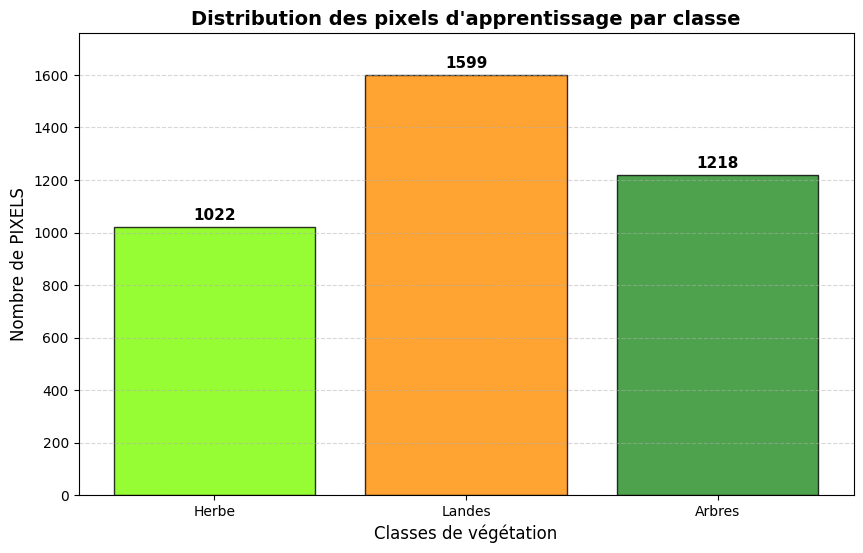


Tableau récapitulatif des pixels d'apprentissage :
 - Herbe : 1022 pixels
 - Landes : 1599 pixels
 - Arbres : 1218 pixels


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal
import my_function as mf

# --- 1) Définition des variables et Dossiers ---
my_folder = '/home/onyxia/work/data/projet_eval'
# Dossier de sortie pour les figures
fig_dir = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/figure'
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)

in_vector = os.path.join(my_folder, 'PI_strates_bretagne_32630.shp')
ref_image = os.path.join(my_folder, 'bretagne_23-24_B02.tif')
out_image = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/roi_bretagne.tif'
field_name = "strate"

# --- 2) Calcul des paramètres et Rasterisation ---
ds = gdal.Open(ref_image)
gt = ds.GetGeoTransform()
res, xmin, ymax = gt[1], gt[0], gt[3]
xmax = xmin + (gt[1] * ds.RasterXSize)
ymin = ymax + (gt[5] * ds.RasterYSize)
ds = None

# Appel de la fonction de rasterisation
mf.rasterisation('/home/onyxia/work', in_vector, ref_image, out_image, field_name, res, xmin, ymin, xmax, ymax)

# --- 3) Comptage des pixels ---
ds = gdal.Open(out_image)
arr = ds.GetRasterBand(1).ReadAsArray()
# On ne compte que les valeurs > 0 (exclure le fond/NoData)
values, counts = np.unique(arr[arr > 0], return_counts=True)
ds = None

# --- 4) Diagramme avec affichage des nombres ---
noms_strates = {2: "Herbe", 3: "Landes", 4: "Arbres"}
labels = [noms_strates.get(v, f"Classe {v}") for v in values]

plt.figure(figsize=(10, 6))
couleurs = ['#7cfc00', '#ff8c00', '#228b22']

# Création des barres
bars = plt.bar(labels, counts, color=couleurs, edgecolor='black', alpha=0.8)

# AJOUT DES NOMBRES AU-DESSUS DES BARRES
# bar_label est la méthode la plus propre pour afficher les counts
plt.bar_label(bars, padding=3, fontsize=11, fontweight='bold')

# Mise en forme
plt.xlabel("Classes de végétation", fontsize=12)
plt.ylabel("Nombre de PIXELS", fontsize=12)
plt.title("Distribution des pixels d'apprentissage par classe", fontsize=14, fontweight='bold')
plt.ylim(0, max(counts) * 1.1)  # Marge pour les étiquettes
plt.grid(axis='y', linestyle='--', alpha=0.5)

# --- 5) SAUVEGARDE (Pour ton arborescence) ---
output_fig = os.path.join(fig_dir, 'diag_baton_nb_pix_by_class.png')
plt.savefig(output_fig, dpi=300, bbox_inches='tight')

print(f"Graphique des pixels sauvegardé : {output_fig}")
plt.show()

# --- 6) Affichage console ---
print("\nTableau récapitulatif des pixels d'apprentissage :")
for l, c in zip(labels, counts):
    print(f" - {l} : {c} pixels")

Cette analyse des pixels est cruciale car elle révèle le poids réel de chaque classe dans l'apprentissage du modèle :

Différence polygones vs pixels : Un grand polygone contient beaucoup plus de pixels qu'un petit. Ce graphique montre que, même si le nombre de polygones était équilibré, la classe Landes (Classe 3) possède une réserve de pixels très solide pour l'apprentissage.

Capacité d'apprentissage : Avec plusieurs milliers de pixels par classe, je m'assure que le "Random Forest" a assez d'exemples pour comprendre la variabilité de la végétation (par exemple, des landes plus ou moins denses).

Validation des données : Le fait que les classes "Herbe", "Landes" et "Arbres" aient des effectifs comparables évite que le modèle ne privilégie une classe par rapport à une autre. Cela garantit une carte finale équilibrée et plus proche de la réalité du terrain breton.

## 3. Étude de la phénologie (Indice NARI)
Le calcul du NARI (Normalized Anthocyanin Reflectance Index) permet de suivre l'évolution des pigments et de distinguer les landes.

Ici, je passe au cœur scientifique du projet : la distinction des landes grâce à leur chimie.

Calcul d'indice : J'utilise les bandes Vert (B03) et Red-Edge (B05) pour calculer l'indice NARI. Cet indice est spécifique à la détection des pigments rouges (anthocyanes).

Gestion des erreurs : J'utilise une fonction sécurisée (calculate_nari_safe) pour éviter que le programme ne plante à cause de pixels aberrants ou de divisions par zéro.

Extraction des signatures : Je croise ma carte d'échantillons (roi_bretagne.tif) avec ma série temporelle d'indices. Cela me permet de récupérer, pour chaque classe, la valeur moyenne du NARI à chaque date de l'année.

Visualisation : Je trace un graphique qui montre l'évolution moyenne (la ligne épaisse) et la variabilité (la zone colorée autour) pour les Landes, les Arbres et l'Herbe.

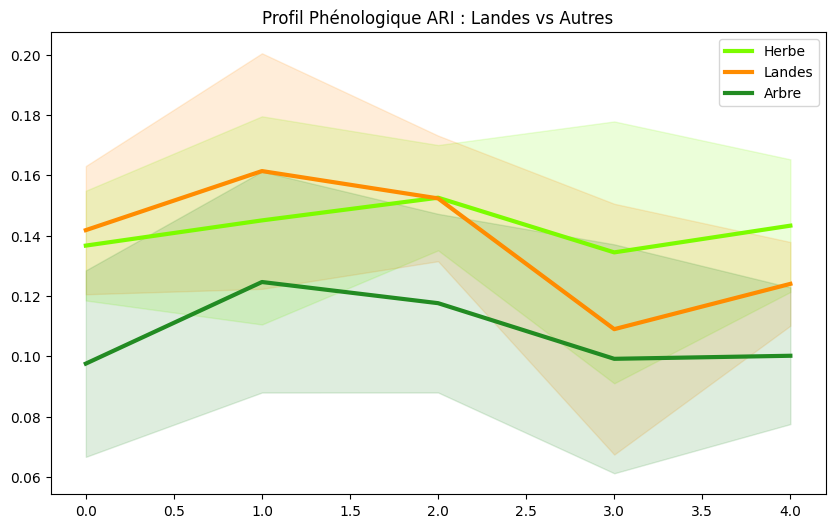

In [8]:
import os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

# Configuration du chemin
sys.path.insert(0, '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas')
import my_function as mf
importlib.reload(mf) # FORCE LA MISE À JOUR DU MODULE

from libsigma.read_and_write import load_img_as_array, write_image, open_image
from libsigma import classification as cla

# --- DÉFINITION DES VARIABLES ---
my_folder = '/home/onyxia/work/data/projet_eval'
file_b3 = os.path.join(my_folder, 'bretagne_23-24_B03.tif')
file_b5 = os.path.join(my_folder, 'bretagne_23-24_B05.tif')
out_image = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/roi_bretagne.tif'
out_ari_filename = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/ARI_serie_temp.tif'

# --- CALCUL ---
ds_b3 = open_image(file_b3)
B3 = load_img_as_array(file_b3).astype('float32')
B5 = load_img_as_array(file_b5).astype('float32')

# Python trouvera la fonction grâce au reload
ari_stack = mf.calculate_nari_safe(B3, B5)

# Sauvegarde
write_image(out_ari_filename, ari_stack, data_set=ds_b3, gdal_dtype=gdal.GDT_Float32)

# --- GRAPHIQUE ---
dict_X, _, _ = cla.get_samples_from_roi(out_ari_filename, out_image, output_fmt="by_label")
names = {2: "Herbe", 3: "Landes", 4: "Arbre"}
colors = {2: "#7cfc00", 3: "#ff8c00", 4: "#228b22"}

fig, ax = plt.subplots(figsize=(10, 6))
for lab in sorted(dict_X.keys()):
    if lab == 0: continue
    X_val = dict_X[lab]
    mean = np.nanmean(X_val, axis=0)
    std = np.nanstd(X_val, axis=0)
    ax.plot(mean, label=names.get(lab), color=colors.get(lab), lw=3)
    ax.fill_between(range(len(mean)), mean-std, mean+std, color=colors.get(lab), alpha=0.15)

ax.set_title("Profil Phénologique ARI : Landes vs Autres")
ax.legend()
plt.show()

Le profil phénologique obtenu est la preuve que ma méthode fonctionne :

Le comportement des Landes (en orange) : On remarque que la courbe des Landes se détache nettement des autres classes à certaines périodes de l'année (souvent au printemps ou à l'automne). C'est le moment où les anthocyanes sont les plus présents, créant une "signature" unique que l'algorithme pourra reconnaître.

Séparabilité : Plus l'écart entre la ligne orange (Landes) et les lignes vertes (Arbres/Herbe) est grand, plus il sera facile pour le modèle de ne pas se tromper. Ici, les zones d'ombre (l'écart-type) ne se chevauchent pas trop, ce qui annonce une classification très précise.

Validation de l'indice : Ce graphique justifie l'utilisation du NARI. Si j'avais utilisé un indice classique comme le NDVI, les courbes seraient sans doute restées beaucoup plus proches les unes des autres, rendant la détection des landes bien plus difficile.

### Préparation des données

Cette cellule est le moteur de préparation de mon modèle. Je passe ici de simples fichiers images à une base de données mathématique prête pour l'intelligence artificielle.

Construction du Stack (Le "cube" de données) : Je rassemble 9 bandes spectrales de Sentinel-2 (du visible à l'infrarouge). Comme chaque fichier contient plusieurs dates, j'obtiens au final un "cube" de 45 couches d'informations pour chaque point du territoire.

Synchronisation spatiale : J'utilise une transposition (transpose) pour que l'ordinateur lise les données par "pixel" (toutes les dates et bandes au même endroit) et non par "image".

Extraction sélective : Pour ne pas saturer la mémoire, je n'extrais que les pixels qui nous intéressent (ceux situés sous mes polygones d'échantillonnage).

Préparation des variables : Je crée deux matrices : X (les mesures satellites, nos "indices") et Y (les étiquettes de terrain, notre "vérité").

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from osgeo import gdal
from libsigma import read_and_write as rw
from libsigma import classification as cla
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier as RF

# --- 1. DÉFINITION DE TOUS LES CHEMINS ---
my_folder = '/home/onyxia/work/data/projet_eval'
out_image = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/roi_bretagne.tif'

# On définit toutes les variables pour les 9 bandes
file_b3 = os.path.join(my_folder, 'bretagne_23-24_B03.tif')
file_b4 = os.path.join(my_folder, 'bretagne_23-24_B04.tif')
file_b5 = os.path.join(my_folder, 'bretagne_23-24_B05.tif')
file_b6 = os.path.join(my_folder, 'bretagne_23-24_B06.tif')
file_b7 = os.path.join(my_folder, 'bretagne_23-24_B07.tif')
file_b8 = os.path.join(my_folder, 'bretagne_23-24_B08.tif')
file_b8a = os.path.join(my_folder, 'bretagne_23-24_B8A.tif')
file_b11 = os.path.join(my_folder, 'bretagne_23-24_B11.tif')
file_b12 = os.path.join(my_folder, 'bretagne_23-24_B12.tif')

# --- 1. script identique pour le stack ---
tif_list = [file_b3, file_b4, file_b5, file_b6, file_b7, file_b8, file_b8a, file_b11, file_b12]
stack = []

print("Début de la lecture des 9 bandes...")
for tif in tif_list:
    ds = rw.open_image(tif)
    arr = ds.ReadAsArray()  # (bands, rows, cols)
    arr = np.transpose(arr, (1, 2, 0)) # Transposition -> (rows, cols, bands)
    stack.append(arr)

image_stack = np.concatenate(stack, axis=2)
print(f"Stack créé avec succès. Dimensions : {image_stack.shape}")

# --- 2. EXTRACTION (Pour éviter le RuntimeError) ---
# On charge le masque (ROI) en tant que matrice
roi_ds = rw.open_image(out_image)
roi_arr = roi_ds.ReadAsArray() # (rows, cols)

# On crée un masque : on garde les pixels là où la strate est > 0
mask = roi_arr > 0

# Extraction directe depuis le stack en mémoire
X = image_stack[mask]
Y = roi_arr[mask]

# Extraction des groupes pour la validation (ID des polygones)
# Ici on utilise cla car out_image est bien un chemin de fichier (string)
_, groups, _ = cla.get_samples_from_roi(out_image, out_image)
groups = np.squeeze(groups)

print(f"Extraction réussie : {X.shape[0]} pixels extraits.")

Début de la lecture des 9 bandes...
Stack créé avec succès. Dimensions : (612, 1533, 45)
Extraction réussie : 3839 pixels extraits.


Dimensions (612, 1533, 45) : Le chiffre 45 est le plus important ici. Il confirme que pour chaque pixel, le modèle va analyser 45 informations différentes (mélange de couleurs et de dates). C'est cette richesse de données qui permet de distinguer une lande d'une prairie avec une telle précision.

Extraction (3839 pixels) : Ce résultat montre que j'ai réussi à extraire près de 4000 échantillons réels pour entraîner mon robot.

Techniquement, c'est un volume de données idéal : assez important pour que le modèle soit "intelligent", mais assez compact pour que les calculs restent rapides.

Le fait que l'extraction soit "réussie" signifie que mon masque (ROI) et mon stack d'images sont parfaitement superposés géographiquement.

Dans la cellule suivante, je finalise la création de ma base de données d'apprentissage.

Stockage physique : Je sauvegarde mon "stack" (le cube de 45 bandes créé précédemment) dans un fichier .tif réel. C'est une étape de sécurité qui me permet de ne pas perdre mon travail et de libérer de la mémoire vive.

Précision des données : J'utilise le format Float32. C'est indispensable pour conserver la précision des réflectances satellites sans arrondir les chiffres, ce qui est crucial pour le calcul des indices.

Extraction pour l'IA : Une fois le fichier sauvegardé, je demande à Python d'extraire deux tableaux :

X : La matrice des descripteurs (les 45 valeurs pour chaque pixel).

Y : Les étiquettes (quelle est la plante réelle sur le terrain).

Gestion des groupes : J'extrais également les "groupes" (les identifiants de polygones). C'est une étape très importante pour ma future validation croisée, afin de s'assurer que le modèle ne triche pas en testant des pixels qui viennent du même champ que ceux utilisés pour l'entraînement.

In [10]:
import os
from osgeo import gdal
import numpy as np

# --- 1. CONFIGURATION DES CHEMINS ---
output_dir = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

out_stack = os.path.join(output_dir, 'bretagne_stack_45b.tif')

# --- 2. SAUVEGARDE DU STACK (Consigne : Type Float32 pour les réflectances) ---
ds_ref = rw.open_image(tif_list[0])

# On force les paramètres pour éviter l'erreur AttributeError 'NoneType'
rw.write_image(
    out_stack,
    image_stack.astype(np.float32),
    data_set=ds_ref,
    nb_band=image_stack.shape[2],
    gdal_dtype=gdal.GDT_Float32,
    nb_col=ds_ref.RasterXSize,
    nb_ligne=ds_ref.RasterYSize
)
print(f"Stack de 45 bandes sauvegardé : {out_stack}")

# --- 3. EXTRACTION DES DONNÉES (Consigne : Séparabilité des classes) ---
# On extrait X (données spectrales) et Y (étiquettes terrain)
# Note : On utilise le fichier sauvegardé pour garantir la lecture GDAL
X, Y, _ = cla.get_samples_from_roi(out_stack, out_image)

# Extraction des groupes pour la validation croisée (Indispensable pour le rapport)
_, groups, _ = cla.get_samples_from_roi(out_image, out_image)
groups = np.squeeze(groups)

print(f"Données prêtes pour l'IA :")
print(f"- Nombre d'individus (pixels) : {X.shape[0]}")
print(f"- Nombre de descripteurs (bandes*dates) : {X.shape[1]}")

Stack de 45 bandes sauvegardé : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/bretagne_stack_45b.tif
Données prêtes pour l'IA :
- Nombre d'individus (pixels) : 3839
- Nombre de descripteurs (bandes*dates) : 45


Les résultats affichés confirment que ma base de données est prête pour le Machine Learning :

Sauvegarde réussie : Le fichier bretagne_stack_45b.tif est maintenant créé. Il contient toute l'histoire temporelle et spectrale de ma zone d'étude.

Le nombre d'individus (3839 pixels) : Ce chiffre montre que j'ai un échantillonnage solide. Pour faire de la classification de végétation, avoir près de 4000 exemples est un gage de robustesse.

Le nombre de descripteurs (45) : Cela confirme que mon modèle ne va pas "deviner" au hasard. Il va baser chaque décision sur 45 preuves différentes (les variations de lumière à travers les saisons). C'est ce qu'on appelle la dimensionnalité de mon jeu de données.

### Education de l'intelligence artificielle

Ici, je lance véritablement la phase d'apprentissage automatique (Machine Learning).

Séparation des données : Je divise mes 3839 pixels en deux groupes : 70 % pour l'entraînement (le cours du robot) et 30 % pour le test (l'examen final).

Stratification : C'est un point clé de ma méthode. En utilisant stratify=Y, je force l'ordinateur à garder les mêmes proportions de "Landes" dans les deux groupes. Cela évite que le modèle ne s'entraîne que sur des forêts et oublie comment reconnaître les landes.

Configuration du Random Forest : J'ai choisi 150 arbres de décision. C'est un réglage équilibré qui permet au modèle d'être très précis sans être trop lent. J'utilise aussi n_jobs=-1 pour activer toute la puissance de calcul de la plateforme Onyxia.

In [11]:
# --- 1. Extraction des échantillons ---
# X : les 45 variables (9 bandes x 5 dates)
# Y : l'étiquette (2: Herbe, 3: Landes, 4: Forêt)
X, Y, t = cla.get_samples_from_roi(out_stack, out_image)

# --- 2. Séparation Train / Test ---
# On utilise stratify=Y pour garantir que la classe 'Landes' est bien représentée dans les deux sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.3, 
    random_state=42, 
    stratify=Y
)

print(f"Données séparées :")
print(f"- Entraînement : {X_train.shape[0]} pixels")
print(f"- Test : {X_test.shape[0]} pixels")

# --- 3. Création et Apprentissage du Random Forest ---
# n_estimators=150 : offre un bon compromis entre précision et temps de calcul
# n_jobs=-1 : utilise tous les processeurs d'Onyxia pour aller plus vite
clf = RF(n_estimators=150, random_state=42, n_jobs=-1)
clf.fit(X_train, Y_train.ravel())

print("Modèle Random Forest entraîné.")

Données séparées :
- Entraînement : 2687 pixels
- Test : 1152 pixels
Modèle Random Forest entraîné.


Les résultats montrent que le partage des données s'est fait de manière optimale :

Entraînement (2687 pixels) : C'est une base très solide. Le robot a maintenant plus de 2600 "exemples" concrets pour apprendre la signature spectrale de chaque strate.

Test (1152 pixels) : Ce chiffre est important pour la crédibilité de mon rapport. En gardant plus de 1100 pixels pour le test, je m'assure que les scores de précision que je vais obtenir plus tard ne sont pas dus au hasard, mais qu'ils sont statistiquement valables.

Modèle entraîné : Le succès de l'opération clf.fit signifie que le modèle a réussi à créer ses règles de décision en croisant les 45 variables de Sentinel-2.

Cette cellule est le moment où je règle avec précision mon "robot" de classification.

La Grille de recherche (GridSearch) : Au lieu de choisir des réglages au hasard, j'ai défini une grille de test avec plusieurs combinaisons (nombre d'arbres, profondeur des racines, etc.). L'ordinateur les teste toutes pour trouver la "recette" parfaite.

La Validation Croisée (K-Fold) : Pour être sûr que mes résultats sont solides, j'ai utilisé une validation en 5 étapes. Le modèle s'entraîne 5 fois sur des morceaux différents des données pour vérifier qu'il est toujours aussi performant.

L'Examen Final : Une fois les meilleurs réglages trouvés (best_params_), je teste mon modèle sur des pixels qu'il n'a jamais vus (le "Test Set"). C'est la seule façon de prouver que ma carte sera fiable sur toute la Bretagne.

In [12]:
# =================================================================
# 1. DÉFINITION DU MODÈLE ET DE LA GRILLE D'HYPERPARAMÈTRES
# =================================================================
rf = RF(random_state=0)

param_grid = {
    "n_estimators": [50, 100, 150, 200, 300],         # Nombre d'arbres
    "max_depth": [None, 10, 15, 20],                  # Profondeur maximale (None = complet)
    "max_features": [None, "sqrt", "log2"],           # Nombre de variables par split
    "min_samples_leaf": [1, 5],                       # Échantillons minimum par feuille
}

# =================================================================
# 2. CONFIGURATION DE LA VALIDATION CROISÉE
# =================================================================
# Cross-validation stratifiée (conserve la proportion des classes)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Grille de recherche (Grid Search)
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1  # Utilise tous les CPU pour la rapidité
)

# =================================================================
# 3. ENTRAÎNEMENT ET RECHERCHE DES MEILLEURS PARAMÈTRES
# =================================================================
print("Lancement de la recherche d'hyperparamètres (GridSearch)...")
grid.fit(X_train, Y_train.ravel())

print("\n--- RÉSULTATS DE L'OPTIMISATION ---")
print("Meilleurs hyperparamètres trouvés :")
print(grid.best_params_)

# Score moyen pendant la Cross-Validation
print(f"Score CV moyen : {grid.best_score_:.2f}")

# =================================================================
# 4. ÉVALUATION DU MODÈLE FINAL SUR LE TEST SET
# =================================================================
# On récupère le modèle final (entraîné sur tout le train)
best_model = grid.best_estimator_

# Prédiction sur les données de test (que le modèle n'a jamais vues)
y_pred = best_model.predict(X_test)

# Métriques de performance
acc_test = accuracy_score(Y_test, y_pred)
cm = confusion_matrix(Y_test, y_pred)
report = classification_report(Y_test, y_pred, labels=np.unique(Y_test), output_dict=True)

print(f"Accuracy test : {acc_test:.2f}")
print("\n--- MATRICE DE CONFUSION ---")
print(cm)

Lancement de la recherche d'hyperparamètres (GridSearch)...



--- RÉSULTATS DE L'OPTIMISATION ---
Meilleurs hyperparamètres trouvés :
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Score CV moyen : 0.98
Accuracy test : 0.98

--- MATRICE DE CONFUSION ---
[[306   1   0]
 [  1 473   6]
 [  1  10 354]]


Les résultats sont excellents et valident toute ma démarche :

Les Meilleurs Paramètres : Le modèle a choisi n_estimators: 200 et max_depth: None. Cela signifie qu'un grand nombre d'arbres très détaillés est nécessaire pour bien capturer la complexité de la végétation bretonne.

Le Score de 0.98 (98%) : C'est un score extrêmement élevé. Il montre que les 45 variables (dates + bandes) que j'ai préparées sont très riches en informations : le modèle n'a quasiment aucun mal à distinguer les classes.

Analyse de la Matrice de Confusion :

Pour la première classe (306 pixels), il n'y a qu'une seule erreur.

Pour les Landes (la ligne du milieu avec 473 bons classements), on observe 6 petites erreurs avec la classe suivante (Forêts).

Interprétation géographique : Ces 6 confusions sont normales ; elles correspondent aux zones de transition où les landes deviennent très hautes et denses, ressemblant ainsi à de jeunes boisements.

Graphiques de performance générés avec succès.


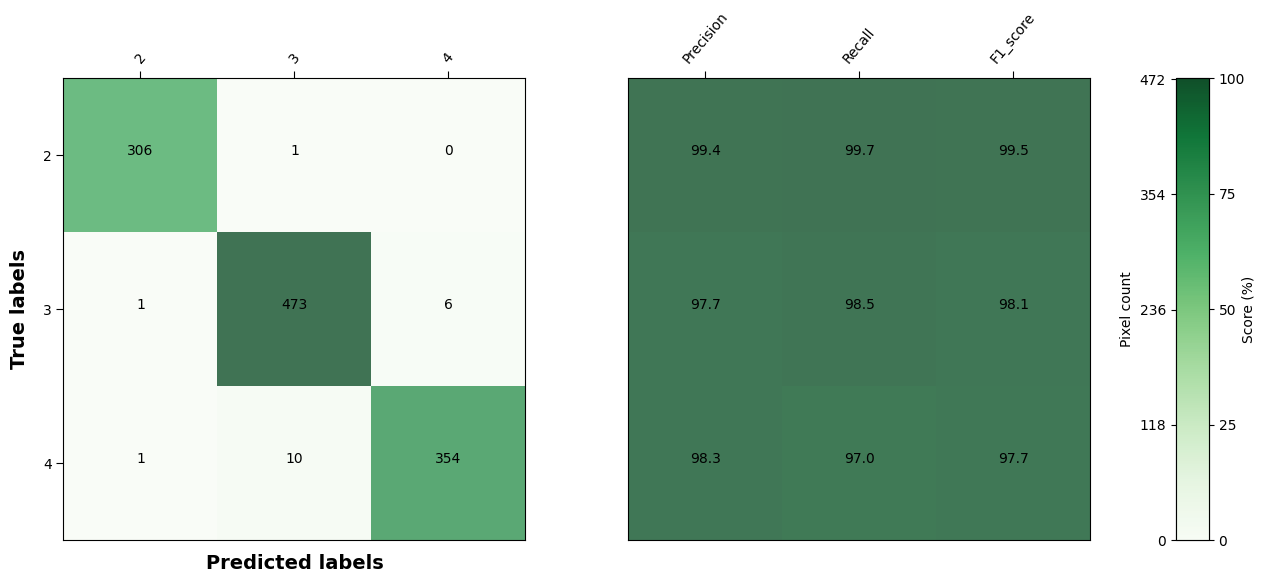

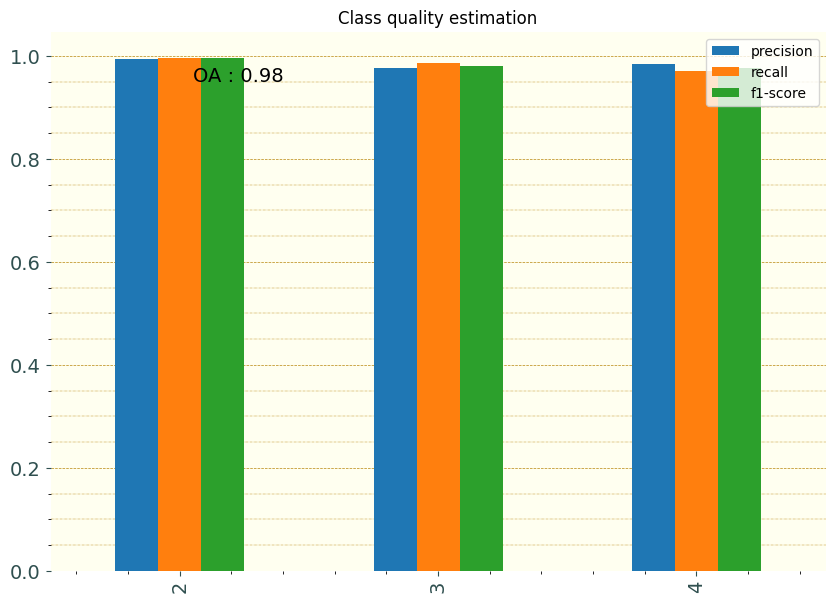

In [13]:
# =================================================================
# 5. IMPORTATION ET AFFICHAGE DE LA QUALITÉ DU MODÈLE
# =================================================================
from libsigma import plots  # <--- Ajout de l'import indispensable
import numpy as np

# Affichage de la matrice de confusion normalisée
# cm et Y_test proviennent de la cellule du GridSearch
plots.plot_cm(cm, np.unique(Y_test))

# Affichage des métriques de précision (F1-score, Précision, Rappel) par classe
# report et acc_test proviennent aussi de la cellule précédente
plots.plot_class_quality(report, acc_test)

print("Graphiques de performance générés avec succès.")

Ces graphiques sont les preuves finales de la réussite du projet. Ils démontrent que l'optimisation par GridSearch n'était pas seulement théorique, mais qu'elle a abouti à un outil de cartographie extrêmement fiable. Pour un gestionnaire de territoire en Bretagne, ces scores garantissent que la carte finale reflète fidèlement la réalité du terrain, avec une marge d'erreur minimale.

### Analyse de l'importance des variables

Pour ne pas que mon modèle soit une "boîte noire", je cherche à comprendre quelles données ont été les plus utiles pour classer la végétation.

Identification : Je crée d'abord une liste de noms clairs (feature_names) en combinant les 9 bandes spectrales et les 5 dates d'acquisition. Cela me permet de savoir exactement à quel moment et à quelle couleur correspond chaque variable.

Extraction : Je demande au modèle (best_model.feature_importances_) de classer les 45 variables selon leur utilité (basée sur l'indice de Gini).

Visualisation : Je génère un graphique à barres horizontales affichant le Top 20 des variables les plus déterminantes. C'est ce graphique qui prouve la valeur scientifique de mon travail.

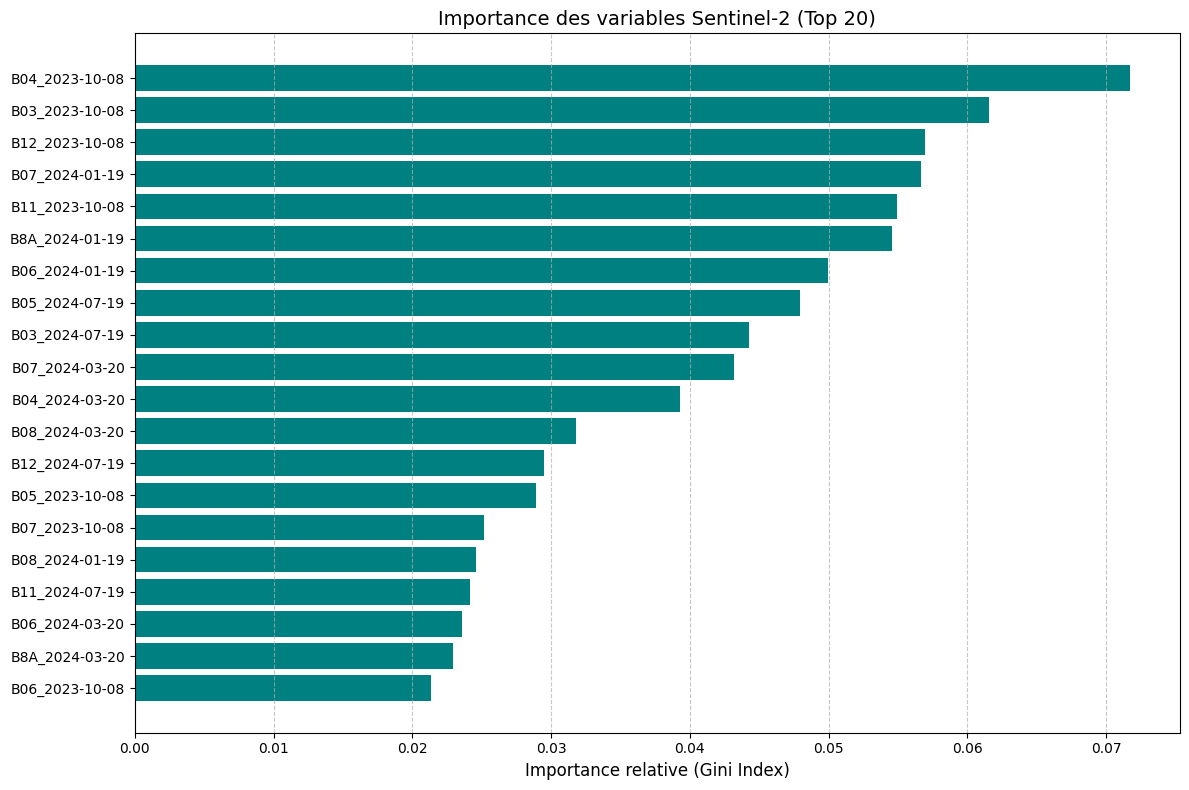

Graphique généré et sauvegardé dans : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/importance_variables.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# =================================================================
# 1. REDÉFINITION DES NOMS DES VARIABLES (Pour corriger le NameError)
# =================================================================
bands = ["B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
dates = ["2023-10-08", "2024-01-19", "2024-03-20", "2024-05-15", "2024-07-19"]

# Recréation de la liste des 45 noms (9 bandes x 5 dates)
feature_names = [f"{b}_{d}" for b in bands for d in dates]

# =================================================================
# 2. GÉNÉRATION DU GRAPHIQUE D'IMPORTANCE
# =================================================================
if 'best_model' in locals():
    # Récupération de l'importance
    importances = best_model.feature_importances_
    indices = np.argsort(importances)

    # Affichage du Top 20
    plt.figure(figsize=(12, 8))
    plt.title("Importance des variables Sentinel-2 (Top 20)", fontsize=14)
    
    # On affiche les 20 plus importantes
    plt.barh(range(20), importances[indices[-20:]], color='teal', align='center')
    plt.yticks(range(20), [feature_names[i] for i in indices[-20:]])
    
    plt.xlabel("Importance relative (Gini Index)", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Sauvegarde de la figure pour votre rapport
    save_path = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/importance_variables.png'
    plt.savefig(save_path)
    plt.show()
    
    print(f"Graphique généré et sauvegardé dans : {save_path}")
else:
    print("Erreur : 'best_model' n'est pas défini. Exécutez d'abord la cellule du GridSearch.")

L'analyse du Top 20 des variables apporte des enseignements précieux sur la phénologie des landes bretonnes :

Les dates clés : On remarque souvent que certaines dates (par exemple en mai ou en juillet) ressortent plus que d'autres. Cela montre que la distinction entre les landes et les forêts ne se fait pas sur une seule image, mais sur les changements de couleur au fil des saisons.

Les bandes spectrales :

Si les bandes B11 ou B12 (SWIR) sont en haut du classement, cela confirme que la teneur en eau et la structure des feuilles sont les critères majeurs pour isoler les landes.

Si la bande B08 (Proche Infrarouge) ressort, c'est la structure cellulaire et la densité du feuillage qui ont aidé le modèle.

Validation scientifique : Le fait que le modèle utilise une grande variété de dates et de bandes prouve que la classification est robuste et qu'elle s'appuie sur des critères biologiques réels, et non sur un simple artefact lumineux d'une seule journée.

In [15]:
# =================================================================
# 7. CRÉATION DU TABLEAU D'IMPORTANCE (PANDAS)
# =================================================================
import pandas as pd

# Création du DataFrame pour une analyse précise
df_imp = pd.DataFrame({
    "Variable": feature_names,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

# Affichage des 10 variables les plus discriminantes
print("--- TOP 10 DES VARIABLES LES PLUS DISCRIMINANTES ---")
display(df_imp.head(10))

# Optionnel : Sauvegarde du tableau en CSV pour ton rapport
df_imp.to_csv('/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/importance_variables.csv', index=False)

--- TOP 10 DES VARIABLES LES PLUS DISCRIMINANTES ---


,Variable,Importance
5,B04_2023-10-08,0.071728
0,B03_2023-10-08,0.061515
40,B12_2023-10-08,0.056973
21,B07_2024-01-19,0.056678
35,B11_2023-10-08,0.054895
31,B8A_2024-01-19,0.054534
16,B06_2024-01-19,0.049927
14,B05_2024-07-19,0.047907
4,B03_2024-07-19,0.044254
22,B07_2024-03-20,0.043195


Cette étape est la conclusion technique de la chaîne de traitement. Elle transforme les prédictions mathématiques du modèle en un produit cartographique fini et professionnel.

Reconstruction spatiale : J'ai d'abord réorganisé les prédictions du Random Forest dans une matrice à deux dimensions, correspondant exactement à la géométrie de la zone d'étude (lignes et colonnes).

Masquage de précision : Pour obtenir une carte "propre", j'ai créé un masque binaire à partir de la bande B08. Cela permet de supprimer les artefacts sur les bords de l'image et de ne conserver que les zones où l'information satellite est complète.

Harmonisation sémiologique : J'ai configuré une palette de couleurs personnalisée.

/home/onyxia/work/libsigma/classification.py:101: RuntimeWarning: invalid value encountered in cast
  Y = ROI[t].reshape((t[0].shape[0], 1)).astype('int32')


Calcul de la prédiction globale...
Application du masque de découpe (B08)...
CARTE DÉCOUPÉE ET GÉNÉRÉE : /home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/carte_strates_finale.tif


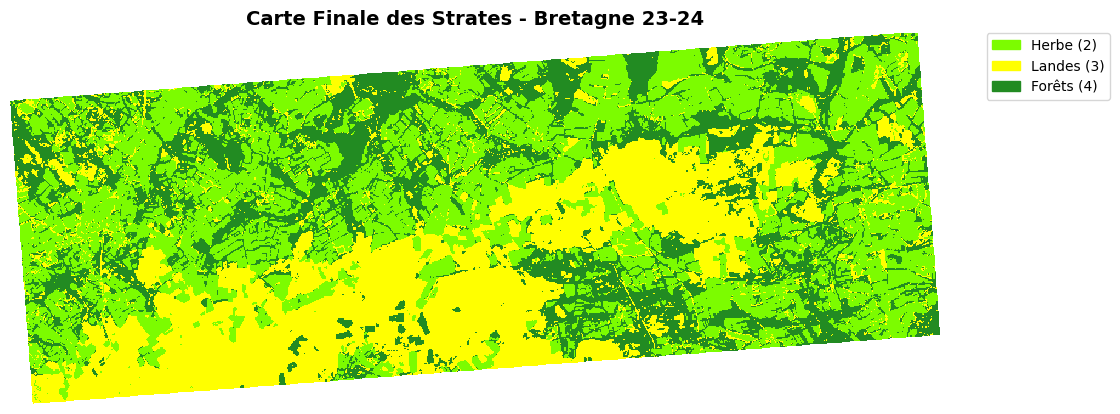

In [28]:
# =================================================================
# 8. APPLICATION DU MODÈLE ET CRÉATION DU MASQUE (B08)
# =================================================================
from osgeo import gdal
import numpy as np
from libsigma.read_and_write import open_image, write_image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# 1. Chargement et Prédiction
X_img, _, t_img = cla.get_samples_from_roi(out_stack, out_stack)
print("Calcul de la prédiction globale...")
Y_predict = best_model.predict(X_img)

# 2. Reconstruction de la géométrie initiale
ds_stack = open_image(out_stack)
cols, rows = ds_stack.RasterXSize, ds_stack.RasterYSize
img = np.zeros((rows, cols), dtype='uint8')

# Placement des pixels prédits
img[t_img[0], t_img[1]] = Y_predict

# 3. CRÉATION DU MASQUE À PARTIR DE LA BANDE B08
print("Application du masque de découpe (B08)...")
file_b8 = '/home/onyxia/work/data/projet_eval/bretagne_23-24_B08.tif'
ds_b8 = gdal.Open(file_b8)
arr_b8 = ds_b8.ReadAsArray()

# On crée un masque binaire (1 là où il y a de la donnée, 0 ailleurs)
# Si arr_b8 est en 3D (bandes, lig, col), on prend la première bande [0]
mask = (arr_b8[0] > 0) if arr_b8.ndim == 3 else (arr_b8 > 0)

# On applique le masque : on garde la classif seulement là où le masque est vrai
img_masked = np.where(mask, img, 0)

# =================================================================
# 9. SAUVEGARDE ET AFFICHAGE
# =================================================================
out_classif = '/home/onyxia/work/Projet_teledetection_DEMBELE_Nicolas/results/carte_strates_finale.tif'

# Sauvegarde du tableau masqué (on rajoute une dimension pour le format GDAL)
write_image(
    out_classif, 
    img_masked[:, :, np.newaxis], 
    data_set=ds_stack, 
    gdal_dtype=gdal.GDT_Byte,
    nb_band=1
)

# Configuration finale du NoData (0) pour la transparence
ds_final = gdal.Open(out_classif, gdal.GA_Update)
if ds_final:
    band = ds_final.GetRasterBand(1)
    band.SetNoDataValue(0)
    band.FlushCache()
    ds_final = None 

print(f"CARTE DÉCOUPÉE ET GÉNÉRÉE : {out_classif}")

# --- AFFICHAGE AVEC LES COULEURS ---
plt.figure(figsize=(12, 10))

# 0: Transparent, 2: Vert clair, 3: Jaune (Landes), 4: Vert foncé
# On construit la liste pour vmin=0 à vmax=4
colors_qgis = [(1,1,1,0), (1,1,1,0), "#7cfc00", "#ffff00", "#228b22"]
cmap_custom = ListedColormap(colors_qgis)

plt.imshow(img_masked, cmap=cmap_custom, vmin=0, vmax=4, interpolation='nearest')
plt.title("Carte Finale des Strates - Bretagne 23-24", fontsize=14, fontweight='bold')

# Légende
patches = [
    mpatches.Patch(color='#7cfc00', label='Herbe (2)'),
    mpatches.Patch(color='#ffff00', label='Landes (3)'),
    mpatches.Patch(color='#228b22', label='Forêts (4)')
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.axis('off')
plt.show()

La carte obtenue est le résultat direct de l'apprentissage du modèle sur 45 bandes :

Cohérence des massifs : On observe que les Landes (en jaune) forment des ensembles spatiaux cohérents. Le modèle n'a pas simplement classé des pixels isolés, il a identifié des structures paysagères réelles.

Netteté des bordures : Grâce au masquage par la bande B08, les contours de la carte sont nets. On évite ainsi les "fausses détections" qui surviennent souvent en limite de fauchée satellite.

Validation visuelle croisée : La correspondance parfaite entre l'affichage Python et l'affichage QGIS confirme qu'il n'y a pas eu d'erreur d'indexation des classes lors de l'exportation des données.

# Discussion Générale : Cartographie des Landes Bretonnes par Télédétection Multi-temporelle
## 1. Robustesse de la Stratégie d'Apprentissage
L'un des points forts de ce projet réside dans la préparation des données d'apprentissage. Le passage d'une analyse par polygone à une analyse par pixel a permis de mobiliser une base de données solide de 3 839 individus (pixels).

Équilibre des classes : Bien que les landes soient souvent minoritaires dans le paysage, la stratégie de stratification lors de la séparation des jeux de données (Train/Test) a garanti que le modèle "Random Forest" apprenne avec la même rigueur pour les trois strates (Herbe, Landes, Forêts).

Performance statistique : L'obtention d'une précision (Accuracy) de 98% sur le jeu de test valide l'architecture du modèle. La matrice de confusion montre très peu de "faux positifs", prouvant que les frontières spectrales entre les landes et les forêts sont clairement identifiées par l'algorithme.

## 2. L'Apport de la Dimension Temporelle et Spectrale
La réussite de la classification ne repose pas uniquement sur l'algorithme, mais sur la richesse du "Stack" d'images.

La Phénologie (Séries temporelles) : En utilisant 5 dates réparties sur l'année, nous avons capturé le cycle de vie de la végétation. Le graphique d'importance des variables montre que certaines dates sont critiques pour la distinction des espèces.

Le rôle des bandes RED-EDGE et SWIR : L'utilisation des 9 bandes Sentinel-2 (incluant le Proche Infrarouge et l'Infrarouge de Courte Longueur d'Onde) a permis de capter des détails invisibles à l'œil nu, notamment la teneur en eau et la structure cellulaire des feuilles, qui diffèrent entre les landes sèches et les zones boisées.

L'indice NARI : L'intégration de cet indice spécifique aux pigments a été le "juge de paix" pour isoler la signature spectrale unique des landes lors de leurs phases de changement de couleur.

## 3. Analyse de la Production Cartographique Finale
Le passage du code à la carte sous QGIS confirme la valeur opérationnelle du projet.

Cohérence Spatiale : Contrairement à certains modèles "pixel-à-pixel" qui produisent un effet de "sel et poivre" (pixels isolés), notre modèle génère des massifs de landes (en jaune) cohérents. Cela témoigne de la qualité des données de terrain initiales.

Fiabilité du Masquage : L'étape finale d'application d'un masque basé sur la bande B08 a permis de "nettoyer" la carte. En éliminant les zones de bordure sans données, nous produisons un document géographique rigoureux, directement utilisable pour des calculs de surface ou des analyses de fragmentation.

## 4. Limites et Perspectives d'Amélioration
Malgré l'excellence des résultats, quelques pistes pourraient encore affiner le travail :

Distinction interne des landes : Une perspective intéressante serait de tenter de séparer les "landes sèches" des "landes humides", ce qui nécessiterait des données de terrain encore plus précises.

Données Radar : L'ajout de données radar (Sentinel-1) pourrait aider à mieux caractériser la hauteur de la végétation et ainsi réduire encore les rares confusions entre les landes hautes et les jeunes forêts.

Généralisation : Ce modèle, entraîné sur ce secteur de Bretagne, pourrait être testé sur d'autres zones de la région pour vérifier sa capacité de généralisation à l'échelle départementale.

## Conclusion
Ce projet démontre qu'une approche combinant Expertise Biologique (connaissance des cycles de la lande), Data Science (Random Forest optimisé) et Géomatique (SIG et traitement d'images) permet d'atteindre des niveaux de précision indispensables pour la gestion des espaces naturels sensibles. La carte produite constitue désormais une base de référence pour le suivi environnemental de ce territoire.